In [67]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [68]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [69]:
device

device(type='cuda')

In [70]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

/tmp/ipython-input-554/2867026071.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [71]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


<Axes: xlabel='Date'>

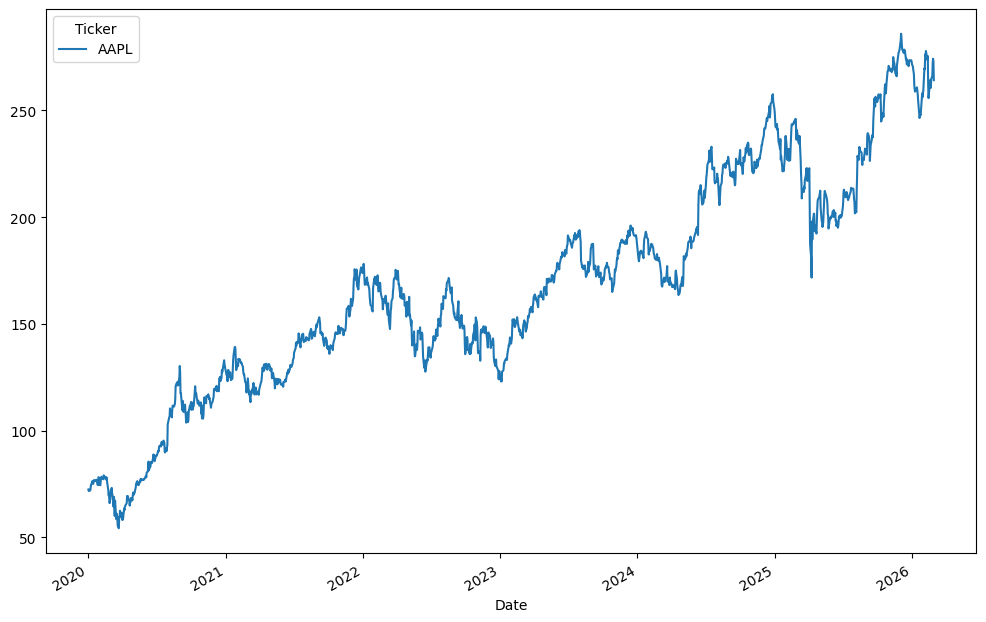

In [72]:
df.Close.plot(figsize=(12, 8))

In [73]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [74]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.845305
2020-01-03,-1.858997
2020-01-06,-1.847884
2020-01-07,-1.854495
2020-01-08,-1.831988
...,...
2026-02-23,1.924049
2026-02-24,2.039982
2026-02-25,2.080636


In [75]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
  data.append(df.Close.values[i:i+seq_length].reshape(-1, 1))

data = np.array(data)

train_size = int(len(data) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [76]:
X_train

tensor([[[-1.8453],
         [-1.8590],
         [-1.8479],
         ...,
         [-1.7423],
         [-1.7514],
         [-1.7158]],

        [[-1.8590],
         [-1.8479],
         [-1.8545],
         ...,
         [-1.7514],
         [-1.7158],
         [-1.7267]],

        [[-1.8479],
         [-1.8545],
         [-1.8320],
         ...,
         [-1.7158],
         [-1.7267],
         [-1.7263]],

        ...,

        [[ 1.2058],
         [ 1.2021],
         [ 1.2183],
         ...,
         [ 1.3378],
         [ 1.3815],
         [ 1.4407]],

        [[ 1.2021],
         [ 1.2183],
         [ 1.2568],
         ...,
         [ 1.3815],
         [ 1.4407],
         [ 1.4477]],

        [[ 1.2183],
         [ 1.2568],
         [ 1.2620],
         ...,
         [ 1.4407],
         [ 1.4477],
         [ 1.4483]]], device='cuda:0')

In [77]:
X_test

tensor([[[1.2568],
         [1.2620],
         [1.1930],
         ...,
         [1.4477],
         [1.4483],
         [1.4444]],

        [[1.2620],
         [1.1930],
         [1.1120],
         ...,
         [1.4483],
         [1.4444],
         [1.5200]],

        [[1.1930],
         [1.1120],
         [1.0541],
         ...,
         [1.4444],
         [1.5200],
         [1.5398]],

        ...,

        [[1.8040],
         [1.8195],
         [1.7983],
         ...,
         [1.8151],
         [1.8929],
         [1.9240]],

        [[1.8195],
         [1.7983],
         [1.7643],
         ...,
         [1.8929],
         [1.9240],
         [2.0400]],

        [[1.7983],
         [1.7643],
         [1.7122],
         ...,
         [1.9240],
         [2.0400],
         [2.0806]]], device='cuda:0')

In [78]:
y_test

tensor([[1.5200],
        [1.5398],
        [1.5150],
        [1.5434],
        [1.5467],
        [1.6030],
        [1.6502],
        [1.5452],
        [1.5788],
        [1.6698],
        [1.6849],
        [1.7415],
        [1.7574],
        [1.6910],
        [1.6255],
        [1.5910],
        [1.4639],
        [1.4544],
        [1.4862],
        [1.4322],
        [1.4417],
        [1.3285],
        [1.2811],
        [1.2594],
        [1.3482],
        [1.1623],
        [1.1956],
        [1.0536],
        [1.0766],
        [1.0733],
        [1.0563],
        [1.1933],
        [1.3558],
        [1.3771],
        [1.3428],
        [1.3121],
        [1.1575],
        [1.2501],
        [1.2438],
        [1.2583],
        [1.1501],
        [1.1554],
        [1.2516],
        [1.3339],
        [1.4242],
        [1.4836],
        [1.4811],
        [1.4889],
        [1.5075],
        [1.5020],
        [1.5321],
        [1.5309],
        [1.4015],
        [1.3423],
        [1.4302],
        [1

In [79]:
y_train

tensor([[-1.7267],
        [-1.7263],
        [-1.7543],
        ...,
        [ 1.4477],
        [ 1.4483],
        [ 1.4444]], device='cuda:0')

In [80]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [81]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [82]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [83]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(f'Epoch {i} loss: {loss.item()}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Epoch 0 loss: 0.7589186429977417
Epoch 25 loss: 0.3125949800014496
Epoch 50 loss: 0.08998015522956848
Epoch 75 loss: 0.04340670630335808
Epoch 100 loss: 0.013635336421430111
Epoch 125 loss: 0.009704294614493847
Epoch 150 loss: 0.00904336478561163
Epoch 175 loss: 0.00863560475409031


In [84]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [85]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [86]:
train_rmse

4.687524318695068

In [87]:
test_rmse

18.448272705078125

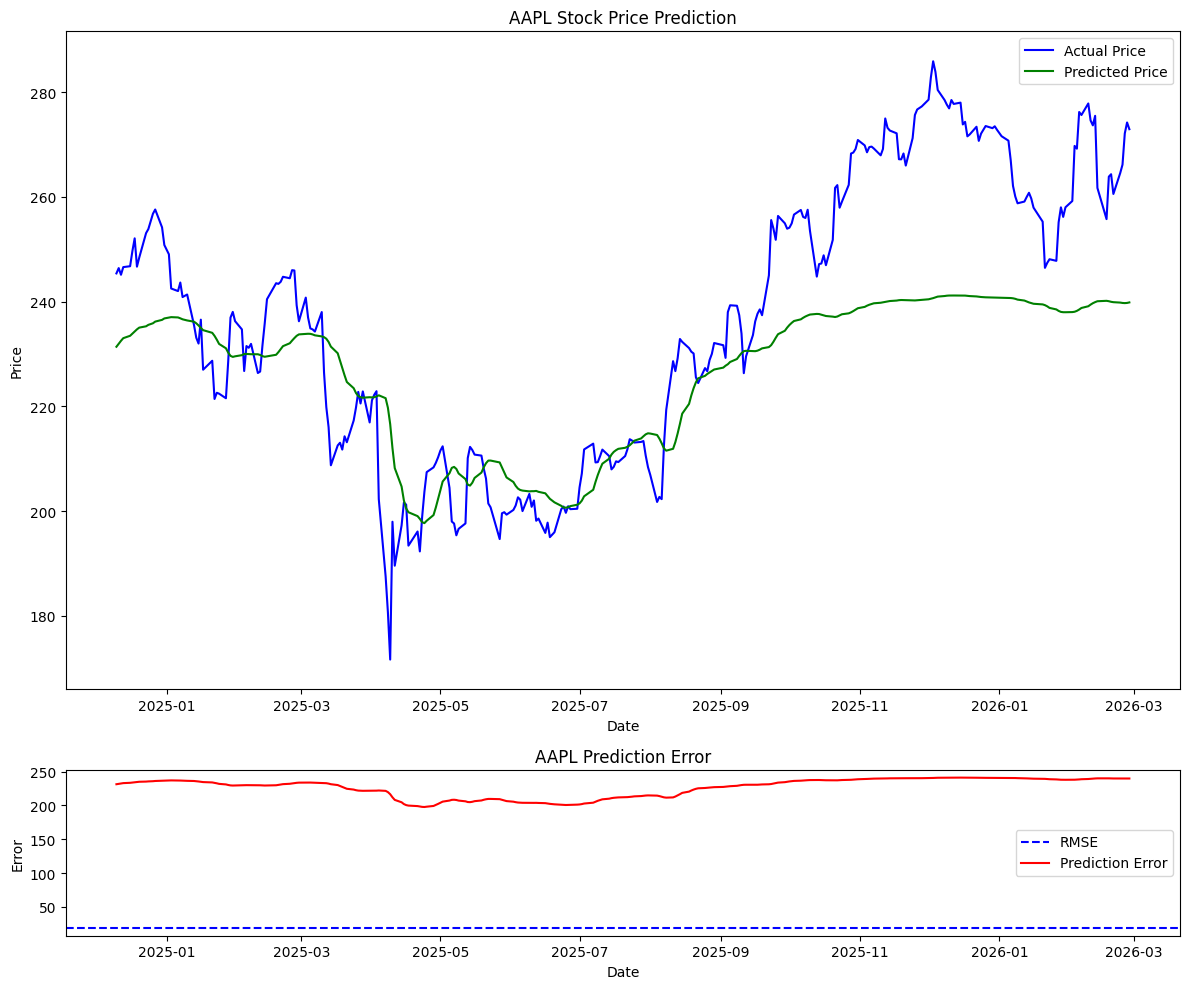

In [88]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title(f"{ticker} Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()

plt.show()
